## Tarefa de Oficina de Modelagem e Simulação

**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 18 de março de 2026  

---

### Descrição
Exercícios computacionais

# Comandos úteis


In [2]:
import numpy as np
import matplotlib.pyplot as plt


"""
Arquivo de comandos que auxiliarão à
realiizar os exercícios computacionais
"""


def cart2pol(x, y):
    r = float(np.sqrt(x**2 + y**2))
    theta = float(np.arctan2(y, x))
    z = r, theta
    return z

def pol2cart(r, theta):
    x = float(r * np.cos(theta))
    y = float(r * np.sin(theta))
    z= complex(x, y)
    return z

def compass(*args):
    """
    Compass plot similar ao MATLAB.

    Uso:
        compass(z)
        compass(u, v)

    Onde:
        z -> vetor de números complexos
        u -> componente x
        v -> componente y
    """

    if len(args) == 1:
        # entrada complexa
        z = np.asarray(args[0])
        u = np.real(z)
        v = np.imag(z)

    elif len(args) == 2 and args[1] == 'polar':
        r, theta = args[0]
        u = r*np.cos(theta)
        v = r*np.sin(theta)

    elif len(args) == 2:
        #entrada cartesiana
        u = np.asarray(args[0])
        v = np.asarray(args[1])

    else:
        raise ValueError("Use compass(z), compass(u,v) ou compass(r,theta,'polar')")

    # origem
    x = np.zeros_like(u)
    y = np.zeros_like(v)

    fig, ax = plt.subplots()

    colors = plt.cm.hsv(np.linspace(0,1,10))


    ax.quiver(x, y, u, v,
              color=colors,
              angles='xy',
              scale_units='xy',
              scale=1)

    # escala automática
    max_val = max(np.max(np.abs(u)), np.max(np.abs(v))) * 1.2

    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)

    ax.set_aspect('equal')
    ax.grid(True)

    plt.show()

def isSquare(A):

    linhas, colunas = A.shape

    if linhas == colunas:
        print("A matriz é quadrada")
    else:
        print("A matriz não é quadrada")



# Exercício 1

(5.0, 0.9272952180016122)
(1.0000000000000002+1.7320508075688772j)


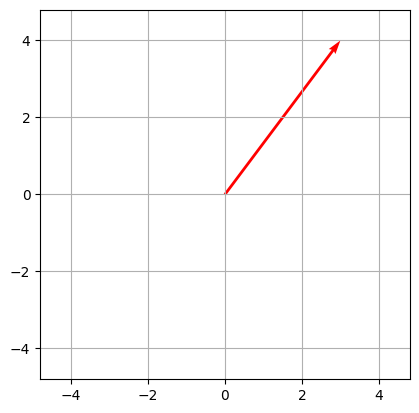

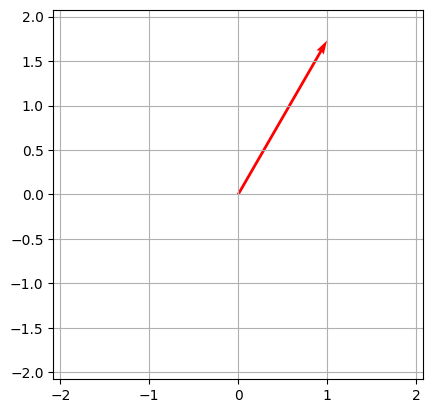

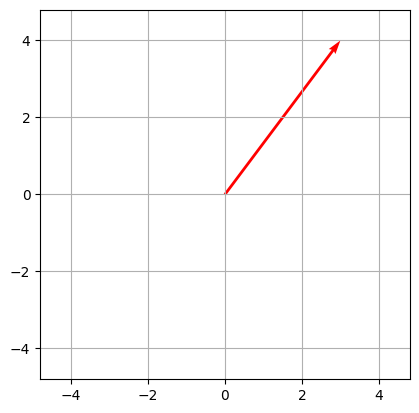

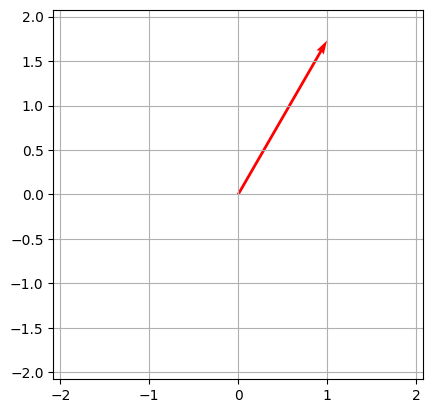

(-3.928203230275508+9.196152422706632j)
(2.482050807568877-0.2990381056766576j)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
#import comandos as cmd


z1 = 3 + 4j
z2 = 2, np.pi/3 # forma polar: r, theta (em radianos)

z1_polar = cart2pol(z1.real, z1.imag)
z2_cart = pol2cart(z2[0], z2[1])

print(z1_polar)
print(z2_cart)

compass(z1)
compass(z2,'polar')
compass(z1_polar,'polar')
compass(z2_cart)

# usa-se a forma cartesiana para multiplicação e divisão
z3 = z1*z2_cart
z4 = z1/z2_cart

print(z3)
print(z4)

# Exercício 2

/var/folders/sj/q_5xy_n50ps10lg75p99wbw80000gn/T/ipykernel_98700/806266878.py:3: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy import signal


Função de transferência G(s):
      1       
──────────────
             2
c⋅s + k + m⋅s 


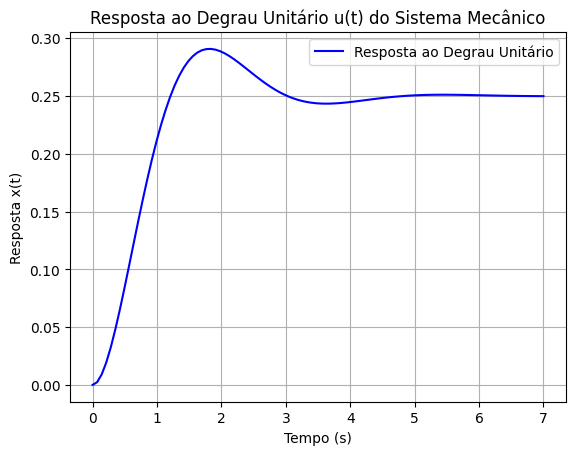

In [6]:
import numpy as np
import sympy as sp
from scipy import signal
import matplotlib.pyplot as plt

"""
    2. O modelo matem´atico de sistemas mecânicos com 1GDL com apenas uma massa m, uma
    mola k e um amortecedor c é dado pela EDOL

                            m*x'' + c*x' + k*x = F(t)

    sendo x(t) a resposta no tempo e f(t) a excitação.


    - Calcular a função de transferência do sistema.

    - Mostrá-la  de forma simbólica usando Matlab. Nota: usar o comando pretty.
    (usaremos python e a biblioteca sympy para isso e o comando pprint, que é equivalente ao pretty).

    - Aplicar uma excitação do tipo degrau unitário e apresentar a resposta x(t) de forma
    gráfica. Assumir os seguintes parâmetros do sistema: m = 1kg, c = 2N.s/m e
    k = 4N/m. Nota: Simular usando o comando step do Matlab.
    (Também usaremos python)
"""
"""
    Calculo da Função de transferência:

        EDO - m*x'' + c*x' + k*x = f(t)
        LT - m*s^2*X(s) + c*s*X(s) + k*X(s) = F(s)
        Fatoriando - > X(s)*(m*s^2 + c*s + k) = F(s)

        Função de transferência - > G(s) = X(s)/F(s) = 1/(m*s^2 + c*s + k)
"""
#----------SEGUNDO ITEM----------
#variáveis simbólicas
s, m, c, k = sp.symbols('s m c k')

#função de transferência
G = 1/(m*s**2 + c*s + k)

#mostrar simpolicamente
print("Função de transferência G(s):")
sp.pprint(G)

#----------TERCEIRO ITEM----------
#parâmetros do sistema
m = 1  # kg
c = 2  # N.s/m
k = 4  # N/m

num = [1]  # Numerador da função de transferência
dem = [m, c, k]  # Denominador da função de transferência

sistema = signal.TransferFunction(num, dem)

t, resposta = signal.step(sistema)

# Plotar a resposta ao degrau
plt.figure()
plt.plot(t, resposta, label='Resposta ao Degrau Unitário', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta x(t)')
plt.title('Resposta ao Degrau Unitário u(t) do Sistema Mecânico')
plt.legend()
plt.grid(True)

plt.show()


# Exercício 3


Função de transferência G(s):
   c⋅s + k    
──────────────
             2
c⋅s + k + m⋅s 


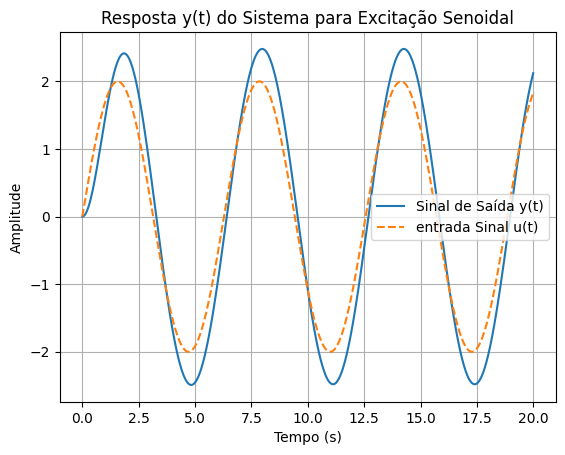

In [8]:
import numpy as np
import sympy as sp
from scipy import signal
import matplotlib.pyplot as plt

"""

    O modelo matemático do sistema mecânico da Figura 18 á dado por

                            mx'' + cx' + kx = cy' + ky

    sendo x(t) o deslocamento da massa ao longo do tempo e y(t) é a
    excitação do tipo deslocamento da base.

    • Calcular a função de transferência do sistema.

    • Mostrá-la de forma simbólica usando Matlab. (Usaremos python/sympy)

    • Aplicar ao sistema uma excitação senoidal com amplitude 2 e frequência 1 rad/s.
    Apresentar a resposta x(t) de forma gráfica. Assumir os seguintes parâmetros do
    sistema: m = 1 kg, c = 2 N.s/m e k = 4 N/m.

    • Calcular a resposta temporal x(t) para a entrada do item anterior.

"""


#Resolução do 1° Item
"""
    EDO - mx'' + cx' + kx = cy' + ky
    LT - m*s^2*X(s) + c*s*X(s) + k*X(s) = c*s*Y(s) + k*Y(s)
    Fatoriando - > X(s)*(m*s^2 + c*s + k) = Y(s)*(c*s + k)

    Função de transferência - > G(s) = X(s)/Y(s) = (c*s + k)/(m*s^2 + c*s + k)
"""


#Resolução do 2° Item
s, m, c, k = sp.symbols('s m c k') #Variaveis simbólicas
G = (c*s + k)/(m*s**2 + c*s + k) #Função de transferência
print("Função de transferência G(s):")
sp.pprint(G)


#Resolução do 3° Item
"""
    m = 1 kg, c = 2 N.s/m e k = 4 N/m.
    G = (2s + 4)/(s^2 + 2s + 4)
"""
m = 1
c = 2
k = 4

num = [c, k] # Numerador da função de transferência
dem = [m, c, k] # Denominador da função de transferência

sistema = signal.TransferFunction(num, dem)

t = np.linspace(0, 20, 1000)

u = 2*np.sin(t) #frequencia 1 e amplitude 2

t_out, y, xout = signal.lsim(sistema, U=u, T=t) # lsim calcula a saída de um sistema submetido a qualquer
                                             # entrada, nesse caso a entrada é a função senoidal
                                             # u(t) = 2*sin(t)

plt.figure()
plt.plot(t_out, y, label="Sinal de Saída y(t)")
plt.plot(t_out, u, label="entrada Sinal u(t)", linestyle='--')
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Resposta y(t) do Sistema para Excitação Senoidal")
plt.legend()
plt.grid()

plt.show()



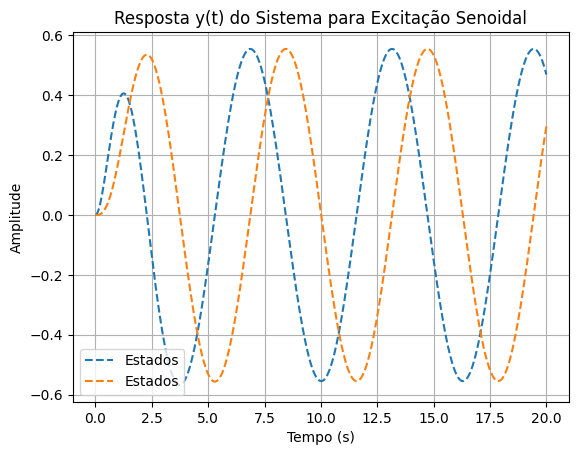

In [9]:
plt.figure()
plt.plot(t_out, xout, label="Estados", linestyle='--')
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Resposta y(t) do Sistema para Excitação Senoidal")
plt.legend()
plt.grid()

plt.show()

# Exercício 4


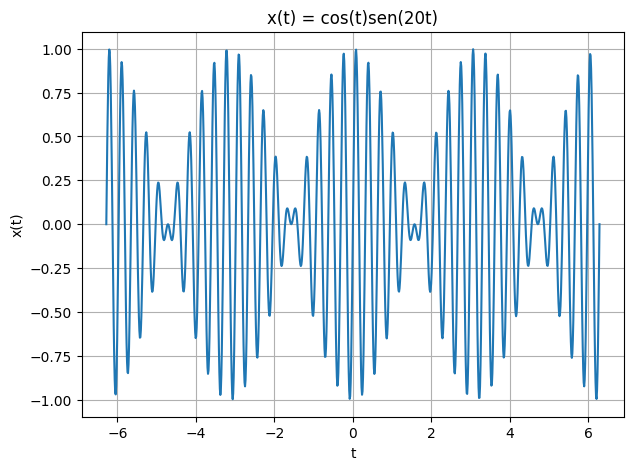

In [11]:
import numpy as np
import matplotlib.pyplot as plt

"""
    Para traçar o gráfico de x(t) = cos(t)sen(20t)
    vamos usar um intervalo de -2pi<=t<=2pi, com 1000 pontos.
"""

#variáveis
t = np.linspace(-2*np.pi, 2*np.pi, 1000)
x = np.cos(t) * np.sin(20*t)

#gráfico
plt.figure("Exemplo 4", figsize=(7, 5))
plt.plot(t, x)
plt.title("x(t) = cos(t)sen(20t)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

plt.show()



# Exercício 5

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp

"""
    Em python, há duas formas de decompor em frações parciais,
    usando sympy, que é mais parecida com a decomposição manual que aprendemos em ASDL,
    e usando scipy, mais utilizada para sinais e sistemas.

    Apesar do sympy prover melhor visualização, ele é mais lento e não é tão prático para sistemas de controle.
    Por isso, aqui usaremos o sympy no primeiro item e o scipy nos outros, para que ambas a s formas fiquem amostradas.
"""

# Item a)
s = sp.symbols('s')
F = (6*(s + 1))/(s*(s+4.46)*(s+0.13))
resultado_a = sp.apart(F)
print("Resposta a):\n", resultado_a)

# Item b)
num_b = [1, 2, 3]
den_b = [1, 2, 1]

r_b, p_b, k_b = signal.residue(num_b, den_b)

print("\nResposta b):")
print("Resíduos:", r_b)
print("Polos:", p_b)
print("Termo direto:", k_b)

# Item c)
num_c = [6, 204]
den_c = [1, 10, 34, 0]

r_c, p_c, k_c = signal.residue(num_c, den_c)

print("\nResposta c):")
print("Resíduos:", r_c)
print("Polos:", p_c)
print("Termo direto:", k_c)

Resposta a):
 -9.04120645613655*(0.2493641214902*s + 1.0)/(0.217864923747277*s**2 + 1.0*s + 0.126318082788671) + 10.3483959986202/s

Resposta b):
Resíduos: [0. 2.]
Polos: [-1. -1.]
Termo direto: [1.]

Resposta c):
Resíduos: [ 6.+0.j -3.+4.j -3.-4.j]
Polos: [ 0.+0.j -5.+3.j -5.-3.j]
Termo direto: []


# Exercício 6

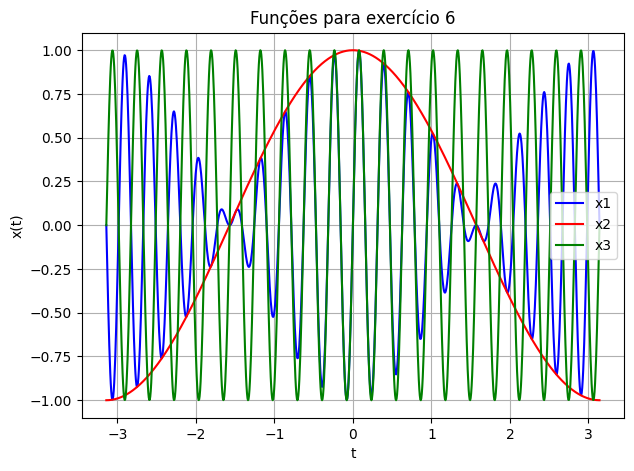

In [15]:
import numpy as np
import matplotlib.pyplot as plt

"""
    6. Trace em apenas um gráfico as funçõeses x1 = cos(t)sen(20t), x2 = cos(t) e x3 = sen(20t).
    Considere faixa e amostragem pertinentes para a variável t. Use legenda e cores para
    discriminar as diferentes funções.
"""

t = np.linspace(-1*np.pi, np.pi, 1000)

x1 = np.cos(t) * np.sin(20*t)
x2 = np.cos(t)
x3 = np.sin(20*t)

#Gráfico
plt.figure("Exemplo 6", figsize=(7, 5))
plt.plot(t, x1, label='x1', color='blue')
plt.plot(t, x2, label='x2', color='red')
plt.plot(t, x3, label='x3', color='green')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Funções para exercício 6')
plt.legend()
plt.grid(True)

plt.show()

# Exercício 7


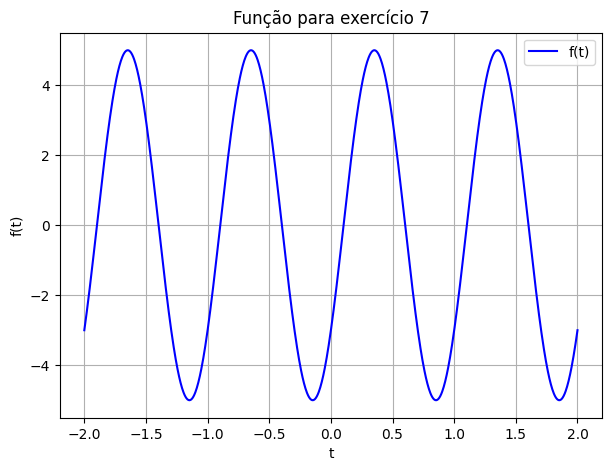

Expressão equivalente: f(t) = 5.00cos(6.28t + -0.64 rad)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

"""
    7. Trace o gráfico de f(t) = -3 cos(ω0t) + 4sen (ω0t) para um valor de ω0 fixo e t variável.
Comente o ocorrido. Obtenha a expressão equivalente de f(t), conforme visualizada no
gráfico.
"""

t = np.linspace(-2, 2, 1000)
omega0 = 2*np.pi # frequência de 1 Hz

f = -3 * np.cos(omega0*t) + 4 * np.sin(omega0*t)

#Gráfico
plt.figure("Exemplo 7", figsize=(7, 5))
plt.plot(t, f, label='f(t)', color='blue')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.title('Função para exercício 7')
plt.legend()
plt.grid(True)

plt.show()

"""
    Comentários:
        A função f(t) = -3 cos(ω0t) + 4sen (ω0t) representa a soma de duas componentes senoidais
        de mesma frequência ω0, mas com amplitudes e fases diferentes. Pela superposição, essa combinação
        resulta em uma única senoide de mesma frequência, mas com amplitude maior e fase deslocada (pela combinação
        dos sinais deslocados). Isso ilustra um conceito fundamental em sinais e sistemas: sinais harmônicos
        de mesma frequência podem ser combinados vetorialmente no plano complexo, preservando a frequência, mas
        alterando amplitude e fase.
"""

#Expressão equivalente:
A = np.sqrt((-3)**2 + 4**2) # Amplitude resultante = 5
phi = np.arctan2(-3, 4) # Fase resultante
f_equiv = A * np.sin(omega0*t + phi)
print(f"Expressão equivalente: f(t) = {A:.2f}cos({omega0:.2f}t + {phi:.2f} rad)") # f(t) = 5.00 cos(ω0t + -0.64 rad)

# Exercício 8


In [19]:
import numpy as np
import matplotlib.pyplot as plt

"""
    Exercícios de análise de matrízes
    a) Determine se A e B são matrizes quadradas. Obs.: O algoritmo deve ser válido para
    avaliar matrizes de quaisquer dimensões.
    b) Quais elementos contêm o valor 2?
    c) Quais elementos contêm valores negativos?
        *Os algoritmos de 'cmd.' estão no arquivo 'comandos.py'
"""

#Matrizes
A = np.array([[1,1,6],
              [5,-2,1],
              [-8,2,-3]])
B = np.array([[2,9],
              [-5,-1],
              [9,2]])
C = np.array([[1,3,5]]) # Para um exemplo com uma dimensão diferente

# Item a)
isSquare(A)
isSquare(B)
isSquare(C)

#Item b)
elementos2_A = np.where(A == 2)
elementos2_B = np.where(B == 2)

print("Elementos iguais a 2 em A:", elementos2_A) #exemplo de saída: (array([2]), array([1])) -> elemento 2 encontrado na linha 2, coluna 1
print("Elementos iguais a 2 em B:", elementos2_B)

#item c)
Negativos_A = np.where(A < 0)
Negativos_B = np.where(B < 0)

print("Elementos negativos em A:", Negativos_A)
print("Elementos negativos em B:", Negativos_B)

A matriz é quadrada
A matriz não é quadrada
A matriz não é quadrada
Elementos iguais a 2 em A: (array([2]), array([1]))
Elementos iguais a 2 em B: (array([0, 2]), array([0, 1]))
Elementos negativos em A: (array([1, 2, 2]), array([1, 0, 2]))
Elementos negativos em B: (array([1, 1]), array([0, 1]))


# Exercício 9

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

"""
    9. Calcule o determinante, a inversa e o traço da matriz simbólica:
        M = [[a,b],
             [c,d]]
    Obs.: Traço é a soma dos elementos da diagonal principal.
"""

a, b, c, d = sp.symbols('a b c d')

M = sp.Matrix([[a, b],
               [c, d]])

D = M.det() # Determinante
I = M.inv() # Inversa
T = M.trace() # Traço

print("Matriz M:\n")
sp.pprint(M)
print("Determinante de M:", D)
print("Inversa de M:\n")
sp.pprint(I)
print("Traço de M:", T)

Matriz M:

⎡a  b⎤
⎢    ⎥
⎣c  d⎦
Determinante de M: a*d - b*c
Inversa de M:

⎡    d         -b    ⎤
⎢─────────  ─────────⎥
⎢a⋅d - b⋅c  a⋅d - b⋅c⎥
⎢                    ⎥
⎢   -c          a    ⎥
⎢─────────  ─────────⎥
⎣a⋅d - b⋅c  a⋅d - b⋅c⎦
Traço de M: a + d


# Exercício 10

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

"""
    Defina uma função f(x) simbólica de quarta ordem e calcule suas derivadas de primeira
    e segunda ordem. Use os comandos diff e pretty.
        *Para isso usaremos o sp.diff (diff) e sp.pprint (pretty) do sympy, que é uma biblioteca de matemática simbólica.
"""

x = sp.symbols('x')
f = x**4 - 5*x**3 + 2*x**2 + x -2

# Derivada Primeira
df = sp.diff(f, x)

# Derivada Segunda
d2f = sp.diff(df, x)

#Impressões
print("Função f(x):\n")
sp.pprint(f)
print("\nDerivada Primeira f'(x):\n")
sp.pprint(df)
print("\nDerivada Segunda f''(x):\n")
sp.pprint(d2f)

Função f(x):

 4      3      2        
x  - 5⋅x  + 2⋅x  + x - 2

Derivada Primeira f'(x):

   3       2          
4⋅x  - 15⋅x  + 4⋅x + 1

Derivada Segunda f''(x):

    2           
12⋅x  - 30⋅x + 4


# Exercício 11

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

"""
    11. Calcule as derivadas de primeira ordem com relação à x dos elementos da matriz simbólica
    M = [[ax, bx^2],
         [cx, dy]]
"""

a, b, c, d, x, y = sp.symbols('a b c d x y')

M = sp.Matrix([[a*x, b*x**2],
               [c*x, d*y]])

# Derivada de cada elemento da matriz M com relação à x
dM_dx = M.diff(x)

print("Matriz original M:\n")
sp.pprint(M)

print("\nDerivada da matriz M com relação à x:\n")
sp.pprint(dM_dx)

Matriz original M:

⎡        2⎤
⎢a⋅x  b⋅x ⎥
⎢         ⎥
⎣c⋅x  d⋅y ⎦

Derivada da matriz M com relação à x:

⎡a  2⋅b⋅x⎤
⎢        ⎥
⎣c    0  ⎦


# Exercício 12


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

"""
    12. Dada a função p(x) = (x^2 - 1)(x - 2)(x - 3). Explore os comandos expand e factor. Comente.
        (Como não estamos em MATLAB, vamos usar a biblioteca sympy, que possui comandos equivalentes)
"""

x = sp.symbols('x')
p = (x**2 - 1)*(x - 2)*(x - 3)

# Expandindo a função p(x)
p_expanded = sp.expand(p)

# Fatorando a função expandida
p_factored = sp.factor(p_expanded)

print("Função original p(x):\n")
sp.pprint(p)
print("\nFunção expandida p(x):\n")
sp.pprint(p_expanded)
print("\nFunção fatorada p(x):\n")
sp.pprint(p_factored)

"""
    Comentário:
        O comando expand() transforma a expressão fatorada em sua forma polinomial expandida,
        enquanto factor() faz o caminho inverso, agrupando os termos em fatores irredutíveis.
        Isso demonstra a capacidade de manipular expressões algébricas simbolicamente,
        útil para simplificação, identificação de raízes e análise de funções.
"""

Função original p(x):

                ⎛ 2    ⎞
(x - 3)⋅(x - 2)⋅⎝x  - 1⎠

Função expandida p(x):

 4      3      2          
x  - 5⋅x  + 5⋅x  + 5⋅x - 6

Função fatorada p(x):

(x - 3)⋅(x - 2)⋅(x - 1)⋅(x + 1)


'\n    Comentário:\n        O comando expand() transforma a expressão fatorada em sua forma polinomial expandida,\n        enquanto factor() faz o caminho inverso, agrupando os termos em fatores irredutíveis.\n        Isso demonstra a capacidade de manipular expressões algébricas simbolicamente,\n        útil para simplificação, identificação de raízes e análise de funções.\n'